In [ ]:
! pip install stlearn

In [1]:
import scanpy as sc

adata = sc.read_h5ad("DLPFC_151507_ST_final.h5ad")

print(adata)
print(adata.obs.columns)
print(adata.obsm.keys())

/Users/muradyan.e/wut/bioinform/.venv/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


AnnData object with n_obs × n_vars = 4221 × 3010
    obs: 'in_tissue', 'array_row', 'array_col', 'Ground Truth', 'n_genes', 'image_cluster', 'dbscan_cluster_new'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_counts'
    uns: 'image_cluster_colors', 'log1p', 'spatial'
    obsm: 'X_pca', 'features', 'features_summary_scale0.5_0.5', 'features_summary_scale0.5_1', 'features_summary_scale0.5_2', 'features_summary_scale1_0.5', 'features_summary_scale1_1', 'features_summary_scale1_2', 'features_summary_scale2_0.5', 'features_summary_scale2_1', 'features_summary_scale2_2', 'spatial'
    obsp: 'adj_f', 'adj_i', 'adj_t'
Index(['in_tissue', 'array_row', 'array_col', 'Ground Truth', 'n_genes',
       'image_cluster', 'dbscan_cluster_new'],
      dtype='object')
KeysView(AxisArrays with keys: X_pca, features, features_summary_scale0.5_0.5, features_summary_scale0.5_1, features_summary_scale0.5_2, features_summary_scale1_0.5, features_summary_scale1_1, features_summary_scale1_2, feat

In [5]:
print((adata.obsm['features_summary_scale0.5_0.5']))

                           summary_ch-0_quantile-0.9  \
AAACAACGAATAGTTC-1_151507                   0.630308   
AAACAAGTATCTCCCA-1_151507                   0.583807   
AAACAATCTACTAGCA-1_151507                   0.615569   
AAACACCAATAACTGC-1_151507                   0.574059   
AAACAGCTTTCAGAAG-1_151507                   0.618906   
...                                              ...   
TTGTTGTGTGTCAAGA-1_151507                   0.581843   
TTGTTTCACATCCAGG-1_151507                   0.588622   
TTGTTTCATTAGTCTA-1_151507                   0.576852   
TTGTTTCCATACAACT-1_151507                   0.591293   
TTGTTTGTGTAAATTC-1_151507                   0.592391   

                           summary_ch-0_quantile-0.5  \
AAACAACGAATAGTTC-1_151507                   0.612204   
AAACAAGTATCTCCCA-1_151507                   0.558400   
AAACAATCTACTAGCA-1_151507                   0.592595   
AAACACCAATAACTGC-1_151507                   0.544304   
AAACAGCTTTCAGAAG-1_151507                   0.6

/var/folders/_t/3h6whhf57fb6936zy09qr12m0000gq/T/ipykernel_12794/1354563210.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="Ground Truth")


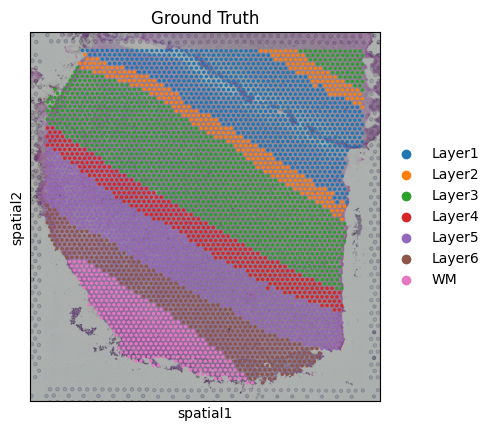

In [2]:
sc.pl.spatial(adata, color="Ground Truth")

In [3]:
adata.obs["Ground Truth"].value_counts()

Ground Truth
Layer3    1215
Layer1     817
Layer5     675
Layer6     486
Layer4     369
WM         354
Layer2     305
Name: count, dtype: int64

### Baseline No Spatial Clustering with Leiden and Kmeans

In [4]:
adata.obs["Ground Truth"] = adata.obs["Ground Truth"].astype("category")

In [5]:
import scanpy as sc

sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.leiden(adata, resolution=0.5)

/Users/muradyan.e/wut/bioinform/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/_t/3h6whhf57fb6936zy09qr12m0000gq/T/ipykernel_12794/4188682848.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=7, random_state=42)
adata.obs["kmeans"] = kmeans.fit_predict(adata.obsm["X_pca"]).astype(str)

/var/folders/_t/3h6whhf57fb6936zy09qr12m0000gq/T/ipykernel_12794/2341126074.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="leiden")


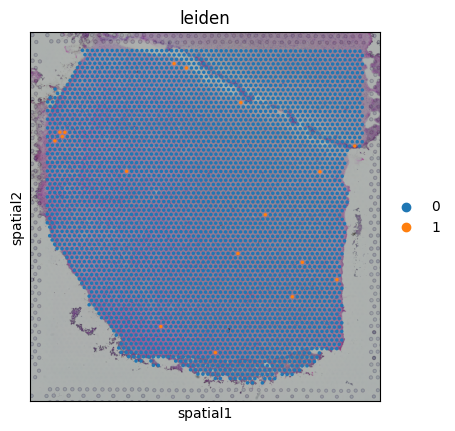

/var/folders/_t/3h6whhf57fb6936zy09qr12m0000gq/T/ipykernel_12794/2341126074.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="kmeans")


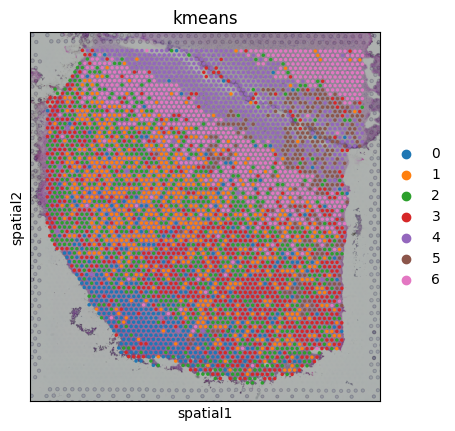

In [7]:
sc.pl.spatial(adata, color="leiden")
sc.pl.spatial(adata, color="kmeans")

### Comparison to Ground Truth

In [8]:
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

ari = adjusted_rand_score(
    adata.obs["Ground Truth"],
    adata.obs["leiden"]
)

nmi = normalized_mutual_info_score(
    adata.obs["Ground Truth"],
    adata.obs["leiden"]
)

print("Leiden ARI:", ari)
print("Leiden NMI:", nmi)

Leiden ARI: -4.5636665402289354e-05
Leiden NMI: 0.0014956737439615327


In [9]:
ari_kmeans = adjusted_rand_score(
    adata.obs["Ground Truth"],
    adata.obs["kmeans"]
)

nmi_kmeans = normalized_mutual_info_score(
    adata.obs["Ground Truth"],
    adata.obs["kmeans"]
)

print("KMeans ARI:", ari_kmeans)
print("KMeans NMI:", nmi_kmeans)

KMeans ARI: 0.17590146621227784
KMeans NMI: 0.2864169320716426


In [10]:
adata.obsm["X_pca"].shape

(4221, 100)

### Rerunning with Top 30 Components


In [18]:
X_30 = adata.obsm["X_pca"][:, :30]

kmeans_30 = KMeans(n_clusters=7, random_state=42)
adata.obs["kmeans_30pc"] = kmeans_30.fit_predict(X_30).astype(str)

sc.pp.neighbors(adata, n_pcs=30)
sc.tl.leiden(adata, resolution=0.5, key_added="leiden_30pc")

In [ ]:
for r in [0.3, 0.5, 0.7, 1.0, 1.2, 1.5]:
    sc.tl.leiden(adata, resolution=r, key_added=f"leiden_{r}")
    print(r, adata.obs[f"leiden_{r}"].nunique())

### Adjusting resolution to make the n clusters closer in number.

In [14]:

ari_l03 = adjusted_rand_score(
    adata.obs["Ground Truth"],
    adata.obs["leiden_0.3"]
)

nmi_l03 = normalized_mutual_info_score(
    adata.obs["Ground Truth"],
    adata.obs["leiden_0.3"]
)

print("Leiden (r=0.3) ARI:", ari_l03)
print("Leiden (r=0.3) NMI:", nmi_l03)

Leiden (r=0.3) ARI: 0.0
Leiden (r=0.3) NMI: 0.0


In [15]:
ari_l30 = adjusted_rand_score(
    adata.obs["Ground Truth"],
    adata.obs["leiden_30pc"]
)

nmi_l30 = normalized_mutual_info_score(
    adata.obs["Ground Truth"],
    adata.obs["leiden_30pc"]
)

print("Leiden (30 PCs) ARI:", ari_l30)
print("Leiden (30 PCs) NMI:", nmi_l30)

Leiden (30 PCs) ARI: 0.2571800035407307
Leiden (30 PCs) NMI: 0.4352370108363352


In [16]:
ari_k30 = adjusted_rand_score(
    adata.obs["Ground Truth"],
    adata.obs["kmeans_30pc"]
)

nmi_k30 = normalized_mutual_info_score(
    adata.obs["Ground Truth"],
    adata.obs["kmeans_30pc"]
)

print("KMeans (30 PCs) ARI:", ari_k30)
print("KMeans (30 PCs) NMI:", nmi_k30)

KMeans (30 PCs) ARI: 0.22229839510585614
KMeans (30 PCs) NMI: 0.34973297991831487


/var/folders/_t/3h6whhf57fb6936zy09qr12m0000gq/T/ipykernel_12794/942250543.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="leiden_0.7")


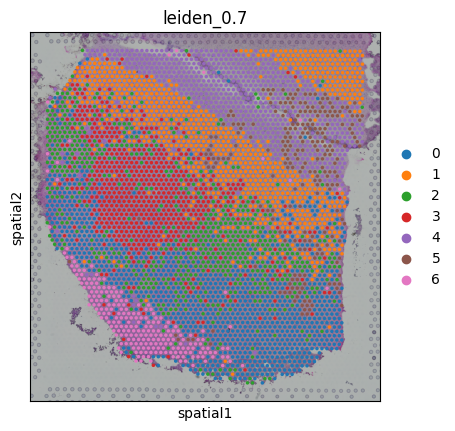

/var/folders/_t/3h6whhf57fb6936zy09qr12m0000gq/T/ipykernel_12794/942250543.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="kmeans_30pc")


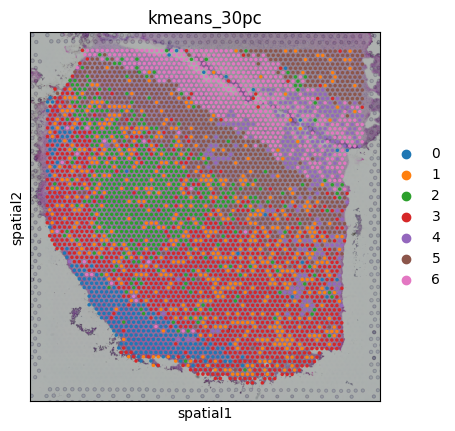

In [20]:
sc.pl.spatial(adata, color="leiden_0.7")
sc.pl.spatial(adata, color="kmeans_30pc")

Spatial proximity likely provides additional structure not captured by expression alone. Spatial proximity can sharpen boundaries that expression-only clustering blurs.

### Experiments with initial ClusterPFN

In [21]:
import transformer
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = transformer.Transformer(
    d_model=256,
    nhead=4,
    nhid=512,
    nlayers=4,
    in_features=5,
    buckets_size=10
).to(device)

checkpoint = torch.load("pfn_hard_5D.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

/Users/muradyan.e/wut/bioinform/.venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


Transformer(
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0, inplace=False)
        (dropout2): Dropout(p=0, inplace=False)
      )
    )
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): Linear(in_features=256, out_features=10, bias=True)
  (linear_x): Linear(in_features=5, out_features=256, bias=True)
  (linear_num_clusters): Linear(in_features=5, out_features=256, bias=True)
  (embedding): E

In [20]:
model.linear_x.weight.shape

torch.Size([256, 5])

In [22]:
import transformer
import torch
checkpoint = torch.load("pfn_hard_5D.pt", map_location="cpu")
print(checkpoint.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'scheduler_last_epoch'])


In [38]:
checkpoint["model_state_dict"]["linear_x.weight"].shape

torch.Size([256, 5])

In [23]:
X = adata.obsm["X_pca"][:, :5]

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:

X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

# reshape to (S, B, F)
X_tensor = X_tensor.unsqueeze(1)

print(X_tensor.shape)

torch.Size([4221, 1, 5])


In [26]:
num_clusters = torch.zeros((4222, 1), dtype=torch.long).to(device)

In [27]:

with torch.no_grad():
    output_points, output_cluster = model(X_tensor, num_clusters)

In [28]:
print(output_points.shape)

torch.Size([4221, 1, 10])


In [29]:
pred = output_points.squeeze(1).argmax(dim=-1)
pred_labels = pred.cpu().numpy()

print(pred_labels.shape)

(4221,)


In [30]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(
    adata.obs["Ground Truth"],
    pred_labels
)

nmi = normalized_mutual_info_score(
    adata.obs["Ground Truth"],
    pred_labels
)

print("Cluster-PFN (5 PCs) ARI:", ari)
print("Cluster-PFN (5 PCs) NMI:", nmi)

Cluster-PFN (5 PCs) ARI: 0.0662379194065785
Cluster-PFN (5 PCs) NMI: 0.06881150064047686


In [31]:
adata.obs["cluster_pfn_5pc"] = pred_labels.astype(str)
adata.obs["cluster_pfn_5pc"] = adata.obs["cluster_pfn_5pc"].astype("category")

/var/folders/_t/3h6whhf57fb6936zy09qr12m0000gq/T/ipykernel_12794/895919916.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


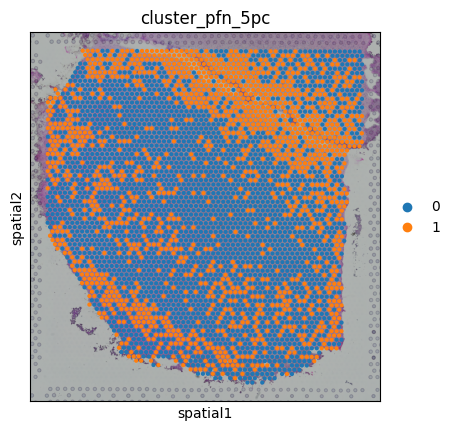

In [32]:
import scanpy as sc

sc.pl.spatial(
    adata,
    color="cluster_pfn_5pc",
    size=1.2
)

/var/folders/_t/3h6whhf57fb6936zy09qr12m0000gq/T/ipykernel_12794/2840662160.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=["Ground Truth", "cluster_pfn_5pc"])


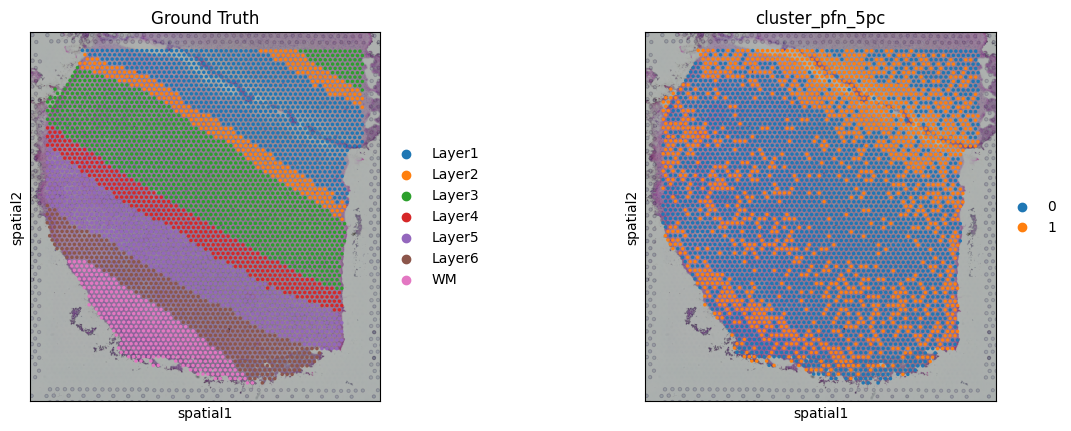

In [33]:
sc.pl.spatial(adata, color=["Ground Truth", "cluster_pfn_5pc"])

In [34]:
import numpy as np

X_expr3 = adata.obsm["X_pca"][:, :3]
X_spatial = adata.obsm["spatial"]

X_combined = np.concatenate([X_expr3, X_spatial], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
X_tensor = X_tensor.unsqueeze(1)  # (S, 1, 5)

In [35]:

with torch.no_grad():
    output_points, output_cluster = model(X_tensor, num_clusters)

In [36]:
pred = output_points.squeeze(1).argmax(dim=-1)
pred_labels = pred.cpu().numpy()

print(pred_labels.shape)

(4221,)


In [37]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(
    adata.obs["Ground Truth"],
    pred_labels
)

nmi = normalized_mutual_info_score(
    adata.obs["Ground Truth"],
    pred_labels
)

print("Cluster-PFN (5 PCs) ARI:", ari)
print("Cluster-PFN (5 PCs) NMI:", nmi)

Cluster-PFN (5 PCs) ARI: 0.05109296804032722
Cluster-PFN (5 PCs) NMI: 0.10027281649245141


In [38]:
adata.obs["cluster_pfn_5pc_exp3"] = pred_labels.astype(str)
adata.obs["cluster_pfn_5pc_exp3"] = adata.obs["cluster_pfn_5pc_exp3"].astype("category")

/var/folders/_t/3h6whhf57fb6936zy09qr12m0000gq/T/ipykernel_75848/1989524194.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=["Ground Truth", "cluster_pfn_5pc_exp3"])


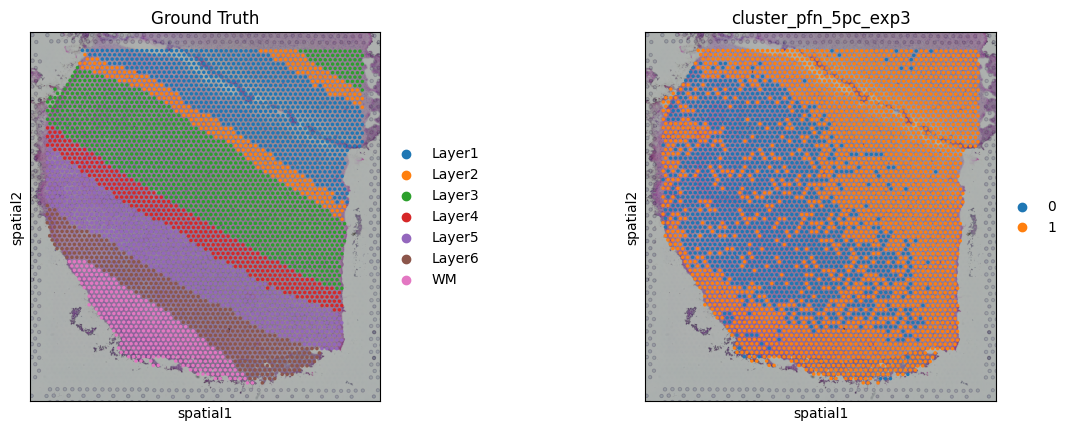

In [39]:
sc.pl.spatial(adata, color=["Ground Truth", "cluster_pfn_5pc_exp3"])